# 04 — EfficientNetB0 Fine-Tuning

**EN3150 Assignment 03 — Resource-Constrained CNN for Edge Image Classification**  
**Owner:** Thiwanka  
**Environment:** Google Colab + TensorFlow/Keras

## Goal

Use ImageNet-pretrained **EfficientNetB0** with the same **17-class UCI Jute Pest 64×64 split** used by the custom models.

Evaluate test accuracy, macro precision, macro recall, parameter count, saved model size, training time, and inference time.

This notebook uses the exact shared 70% / 15% / 15% split created by Sahanya.

In [ ]:
%pip install -q scikit-learn

In [ ]:
import os
import gc
import time
import json
import random
import shutil
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

In [ ]:
SEED = 42
IMG_SIZE = 64
BATCH_SIZE = 64

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("SEED =", SEED)
print("IMG_SIZE =", IMG_SIZE)
print("BATCH_SIZE =", BATCH_SIZE)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

MEMBER = "thiwanka"

# ----------------------------------------------------
# Personal storage: dataset cache, checkpoints, plots
# ----------------------------------------------------
PERSONAL_ROOT = Path(
    f"/content/drive/MyDrive/EN3150_A03_PERSONAL/{MEMBER}"
)

DATA_ROOT = PERSONAL_ROOT / "dataset_cache" / "jute_pest"
ARTIFACT_ROOT = PERSONAL_ROOT / "artifacts" / "jute_pest"
PLOT_ROOT = PERSONAL_ROOT / "plots" / "jute_pest"

for p in [
    DATA_ROOT,
    ARTIFACT_ROOT,
    PLOT_ROOT,
]:
    p.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------
# Group-shared folder
# ----------------------------------------------------
# Add EN3150_A03_SHARED as a shortcut inside My Drive first.
SHARED_ROOT = Path(
    "/content/drive/MyDrive/EN3150_A03_SHARED"
)

if not SHARED_ROOT.exists():
    raise FileNotFoundError(
        "EN3150_A03_SHARED was not found in My Drive. "
        "Add the shared folder as a shortcut inside My Drive, "
        "then rerun this cell."
    )

RESULT_ROOT = (
    SHARED_ROOT
    / "shared_results_jute_pest"
)

RESULT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

MANIFEST_PATH = (
    RESULT_ROOT
    / "jute_pest_split_manifest.csv"
)

SUMMARY_PATH = (
    RESULT_ROOT
    / "dataset_summary.json"
)

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        "jute_pest_split_manifest.csv is missing. "
        "Sahanya must run the shared data notebook first."
    )

if not SUMMARY_PATH.exists():
    raise FileNotFoundError(
        "dataset_summary.json is missing. "
        "Sahanya must run the shared data notebook first."
    )

print("Personal root:", PERSONAL_ROOT)
print("Dataset cache:", DATA_ROOT)
print("Artifact root:", ARTIFACT_ROOT)
print("Shared results:", RESULT_ROOT)

In [ ]:
# ============================================================
# UCI JUTE PEST DATASET — USE THE EXACT SHARED GROUP SPLIT
# ============================================================

DATASET_URL = (
    "https://archive.ics.uci.edu/static/public/920/"
    "jute+pest+dataset.zip"
)

ZIP_PATH = DATA_ROOT / "jute_pest_dataset.zip"
EXTRACT_DIR = DATA_ROOT / "extracted"

# ------------------------------------------------------------
# 1. Download once to this member's personal Google Drive
# ------------------------------------------------------------
if not ZIP_PATH.exists():

    print("Downloading UCI Jute Pest dataset...")

    temp_zip = ZIP_PATH.with_suffix(".part")

    if temp_zip.exists():
        temp_zip.unlink()

    urllib.request.urlretrieve(
        DATASET_URL,
        temp_zip
    )

    temp_zip.replace(ZIP_PATH)

    print("Download complete.")

else:

    print(
        "Using cached ZIP:",
        ZIP_PATH
    )


if not zipfile.is_zipfile(ZIP_PATH):
    raise RuntimeError(
        "The cached UCI file is not a valid ZIP."
    )


# ------------------------------------------------------------
# 2. Extract outer UCI ZIP
# ------------------------------------------------------------
EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

outer_marker = (
    EXTRACT_DIR
    / ".outer_extraction_complete"
)

if not outer_marker.exists():

    print("Extracting outer UCI archive...")

    with zipfile.ZipFile(
        ZIP_PATH,
        "r"
    ) as zf:

        zf.extractall(
            EXTRACT_DIR
        )

    outer_marker.write_text(
        "Outer ZIP extracted",
        encoding="utf-8"
    )

    print("Outer archive extracted.")

else:

    print("Outer archive already extracted.")


# ------------------------------------------------------------
# 3. Extract nested ZIP files recursively
# ------------------------------------------------------------
def extract_nested_zips(root_folder):

    processed = set()

    while True:

        nested_zips = [
            p
            for p in root_folder.rglob("*.zip")
            if str(p.resolve()) not in processed
        ]

        if not nested_zips:
            break

        for nested_zip in nested_zips:

            processed.add(
                str(nested_zip.resolve())
            )

            target_folder = (
                nested_zip.parent
                / f"{nested_zip.stem}_extracted"
            )

            marker = (
                target_folder
                / ".extraction_complete"
            )

            if marker.exists():
                continue

            print(
                "Extracting nested ZIP:",
                nested_zip.name
            )

            target_folder.mkdir(
                parents=True,
                exist_ok=True
            )

            if not zipfile.is_zipfile(
                nested_zip
            ):
                continue

            with zipfile.ZipFile(
                nested_zip,
                "r"
            ) as zf:

                zf.extractall(
                    target_folder
                )

            marker.write_text(
                "Nested ZIP extracted",
                encoding="utf-8"
            )


extract_nested_zips(
    EXTRACT_DIR
)


# ------------------------------------------------------------
# 4. Load shared metadata and exact split manifest
# ------------------------------------------------------------
with open(
    SUMMARY_PATH,
    "r"
) as f:

    dataset_summary = json.load(f)


CLASS_NAMES = dataset_summary["classes"]
NUM_CLASSES = int(
    dataset_summary["num_classes"]
)

assert NUM_CLASSES == 17


manifest = pd.read_csv(
    MANIFEST_PATH
)

required_columns = {
    "relative_path",
    "label",
    "class_name",
    "split",
}

assert required_columns.issubset(
    manifest.columns
)


# ------------------------------------------------------------
# 5. Rebuild this member's local Drive paths
# ------------------------------------------------------------
def build_split(split_name):

    part = (
        manifest[
            manifest["split"]
            == split_name
        ]
        .copy()
        .reset_index(drop=True)
    )

    paths = np.asarray(
        [
            str(
                EXTRACT_DIR
                / rel_path
            )
            for rel_path
            in part[
                "relative_path"
            ].astype(str)
        ],
        dtype=str,
    )

    split_labels = (
        part["label"]
        .to_numpy(
            dtype=np.int32
        )
    )

    missing = [
        p
        for p in paths
        if not Path(p).exists()
    ]

    if missing:

        print(
            "Example missing path:",
            missing[0]
        )

        raise FileNotFoundError(
            f"{len(missing)} manifest images were not found. "
            "Make sure the Jute Pest dataset was extracted correctly."
        )

    return paths, split_labels


train_paths, train_labels = build_split(
    "train"
)

val_paths, val_labels = build_split(
    "validation"
)

test_paths, test_labels = build_split(
    "test"
)


print("Classes:", NUM_CLASSES)
print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))


# ------------------------------------------------------------
# 6. Build raw TensorFlow datasets
# ------------------------------------------------------------
def decode_image(path, label):

    image_bytes = tf.io.read_file(
        path
    )

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )

    image.set_shape(
        [None, None, 3]
    )

    return image, label


raw_train = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            train_paths,
            train_labels
        )
    )
    .map(
        decode_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
)

raw_val = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            val_paths,
            val_labels
        )
    )
    .map(
        decode_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
)

raw_test = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            test_paths,
            test_labels
        )
    )
    .map(
        decode_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
)


def count_examples(ds):

    return int(
        tf.data.experimental
        .cardinality(ds)
        .numpy()
    )


print()
print("TensorFlow cardinality")
print("----------------------")
print("Train:", count_examples(raw_train))
print("Validation:", count_examples(raw_val))
print("Test:", count_examples(raw_test))

print()
print(
    "Shared UCI Jute Pest split loaded successfully."
)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(
    image,
    label
):

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE],
        antialias=True,
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


# Cache first, then reshuffle training samples each epoch.
train_ds = (
    raw_train
    .map(
        preprocess,
        num_parallel_calls=AUTOTUNE
    )
    .cache()
    .shuffle(
        4096,
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    raw_val
    .map(
        preprocess,
        num_parallel_calls=AUTOTUNE
    )
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    raw_test
    .map(
        preprocess,
        num_parallel_calls=AUTOTUNE
    )
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(
    "Training batches:",
    tf.data.experimental
    .cardinality(train_ds)
    .numpy()
)

print(
    "Validation batches:",
    tf.data.experimental
    .cardinality(val_ds)
    .numpy()
)

print(
    "Test batches:",
    tf.data.experimental
    .cardinality(test_ds)
    .numpy()
)

## Build EfficientNetB0

In [ ]:
def build_eff():

    inp = keras.Input(
        (
            IMG_SIZE,
            IMG_SIZE,
            3
        ),
        name="image"
    )

    base = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        ),
    )

    base.trainable = False

    x = base(
        inp,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(
        0.2
    )(x)

    out = layers.Dense(
        NUM_CLASSES,
        name="logits"
    )(x)

    return (
        keras.Model(
            inp,
            out,
            name="EfficientNetB0_Jute_Pest"
        ),
        base.name
    )


eff, BASE_NAME = build_eff()

eff.summary()

print(
    "Total:",
    eff.count_params(),
    "Trainable:",
    int(
        sum(
            np.prod(v.shape)
            for v
            in eff.trainable_weights
        )
    )
)

---
### ✅ Git commit checkpoint
Do **not** commit every cell. Commit after this meaningful milestone.

Suggested commit:
```text
feat: add EfficientNetB0 transfer learning architecture
```
File:
```text
notebooks/04_efficientnetb0.ipynb
```
Beginner workflow: **Colab → File → Download `.ipynb` → replace local notebook → GitHub Desktop → Commit → Push**.

## Stage 1 — train classifier head

In [ ]:
LOSS_FN=keras.losses.SparseCategoricalCrossentropy(from_logits=True)
class PersistentEpochTimer(keras.callbacks.Callback):
    def __init__(self,csv_path): super().__init__(); self.csv_path=Path(csv_path); self.csv_path.parent.mkdir(parents=True,exist_ok=True)
    def on_epoch_begin(self,epoch,logs=None): self.start=time.perf_counter()
    def on_epoch_end(self,epoch,logs=None):
        row=pd.DataFrame([{'epoch':int(epoch),'seconds':float(time.perf_counter()-self.start)}])
        row.to_csv(self.csv_path,mode='a',header=not self.csv_path.exists(),index=False)
def read_log(run_name):
    p=ARTIFACT_ROOT/run_name/'training_log.csv'
    if not p.exists(): return pd.DataFrame()
    d=pd.read_csv(p)
    return d.drop_duplicates(subset=['epoch'],keep='last').sort_values('epoch') if 'epoch' in d else d
def average_epoch_time(run_name):
    p=ARTIFACT_ROOT/run_name/'epoch_times.csv'
    if not p.exists(): return np.nan
    d=pd.read_csv(p).drop_duplicates(subset=['epoch'],keep='last')
    return float(d.seconds.mean()) if len(d) else np.nan
def fit_resumable(model,run_name,optimizer,epochs):
    rd=ARTIFACT_ROOT/run_name; rd.mkdir(parents=True,exist_ok=True)
    final=rd/'final.keras'; best=rd/'best.keras'; backup=rd/'backup'; log=rd/'training_log.csv'; timing=rd/'epoch_times.csv'
    if final.exists(): print('Completed run found:',run_name); return keras.models.load_model(final)
    model.compile(optimizer=optimizer,loss=LOSS_FN,metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')])
    callbacks=[keras.callbacks.BackupAndRestore(backup_dir=str(backup),save_freq='epoch',delete_checkpoint=False),keras.callbacks.ModelCheckpoint(str(best),monitor='val_accuracy',mode='max',save_best_only=True,verbose=1),keras.callbacks.CSVLogger(str(log),append=True),PersistentEpochTimer(timing)]
    model.fit(train_ds,validation_data=val_ds,epochs=epochs,callbacks=callbacks,verbose=1)
    model.save(final); return model
def reset_run(run_name):
    import shutil
    p=ARTIFACT_ROOT/run_name
    if p.exists(): shutil.rmtree(p)
def plot_history(run_name,prefix):
    d=read_log(run_name)
    plt.figure(figsize=(8,5)); plt.plot(d.epoch+1,d.loss,label='Train'); plt.plot(d.epoch+1,d.val_loss,label='Validation'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(prefix+' Loss'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.savefig(PLOT_ROOT/(prefix.lower().replace(' ','_')+'_loss.png'),dpi=180); plt.show()
    plt.figure(figsize=(8,5)); plt.plot(d.epoch+1,d.accuracy,label='Train'); plt.plot(d.epoch+1,d.val_accuracy,label='Validation'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title(prefix+' Accuracy'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.savefig(PLOT_ROOT/(prefix.lower().replace(' ','_')+'_accuracy.png'),dpi=180); plt.show()

In [10]:
STAGE1_RUN = (
    "efficientnetb0_jute_stage1"
)

eff, BASE_NAME = build_eff()

eff = fit_resumable(
    eff,
    STAGE1_RUN,
    keras.optimizers.Adam(
        1e-3
    ),
    5
)

Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2611 - loss: 2.4116
Epoch 1: val_accuracy improved from None to 0.64793, saving model to /content/drive/MyDrive/EN3150_A03_PERSONAL/thiwanka/artifacts/jute_pest/efficientnetb0_jute_stage1/best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/EN3150_A03_PERSONAL/thiwanka/artifacts/jute_pest/efficientnetb0_jute_stage1/best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 389s 5s/step - accuracy: 0.4125 - loss: 2.0234 - val_accuracy: 0.6479 - val_loss: 1.3761
Epoch 2/5
78/80 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6462 - loss: 1.3121
Epoch 2: val_accuracy improved from 0.64793 to 0.73917, saving model to /content/drive/MyDrive/EN3150_A03_PERSONAL/thiwanka/artifacts/jute_pest/efficientnetb0_jute_stage1/best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/EN3150_A03_PERSONAL/thiwanka/artifacts/jute_pest/efficientnetb0_jute_stage1/best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.6698 - loss: 

## Stage 2 — fine tune last 20 backbone layers

In [11]:
def unfreeze_last(model,base_name,n=20):
    base=model.get_layer(base_name); base.trainable=True
    for l in base.layers[:-n]: l.trainable=False
    for l in base.layers[-n:]: l.trainable=not isinstance(l,layers.BatchNormalization)
    return model
eff=unfreeze_last(eff,BASE_NAME,20); print('Trainable now:',int(sum(np.prod(v.shape) for v in eff.trainable_weights)))

Trainable now: 1364545


Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8483 - loss: 0.5999
Epoch 1: val_accuracy improved from None to 0.83687, saving model to /content/drive/MyDrive/EN3150_A03_PERSONAL/thiwanka/artifacts/jute_pest/efficientnetb0_jute_stage2/best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/EN3150_A03_PERSONAL/thiwanka/artifacts/jute_pest/efficientnetb0_jute_stage2/best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 51s 340ms/step - accuracy: 0.8448 - loss: 0.5766 - val_accuracy: 0.8369 - val_loss: 0.5784
Epoch 2/10
78/80 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8542 - loss: 0.5239
Epoch 2: val_accuracy improved from 0.83687 to 0.83871, saving model to /content/drive/MyDrive/EN3150_A03_PERSONAL/thiwanka/artifacts/jute_pest/efficientnetb0_jute_stage2/best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/EN3150_A03_PERSONAL/thiwanka/artifacts/jute_pest/efficientnetb0_jute_stage2/best.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8539 -

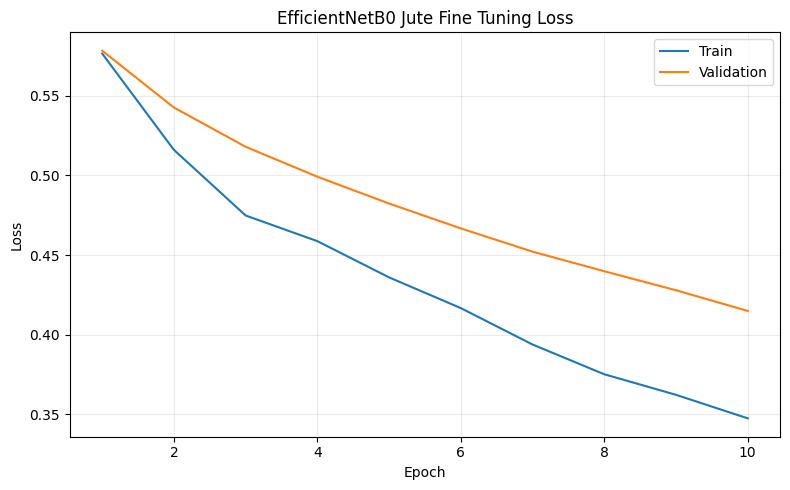

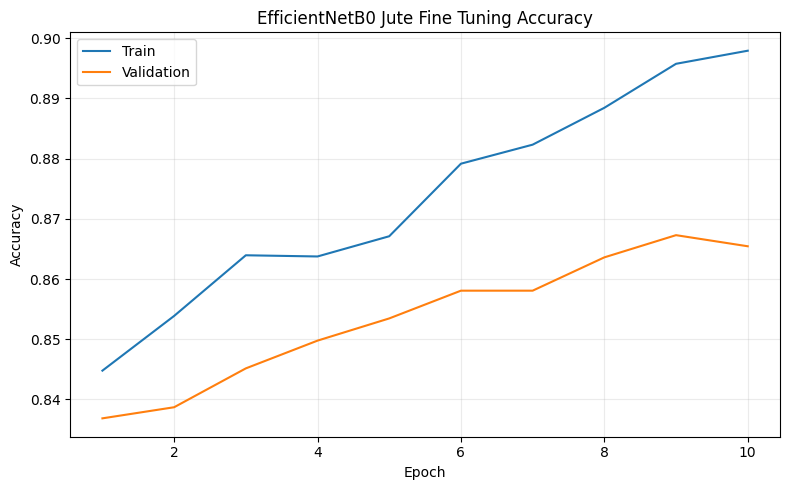

In [12]:
STAGE2_RUN = (
    "efficientnetb0_jute_stage2"
)

eff = fit_resumable(
    eff,
    STAGE2_RUN,
    keras.optimizers.Adam(
        1e-5
    ),
    10
)

plot_history(
    STAGE2_RUN,
    "EfficientNetB0 Jute Fine Tuning"
)

---
### ✅ Git commit checkpoint
Do **not** commit every cell. Commit after this meaningful milestone.

Suggested commit:
```text
exp: train and fine tune EfficientNetB0
```
File:
```text
notebooks/04_efficientnetb0.ipynb
```
Beginner workflow: **Colab → File → Download `.ipynb` → replace local notebook → GitHub Desktop → Commit → Push**.

## Test evaluation

In [ ]:
def get_true_labels(ds):
    return np.concatenate(
        [
            y.numpy()
            for _, y
            in ds
        ]
    )


Y_TEST = get_true_labels(
    test_ds
)


def model_file_size_mb(path):
    return (
        Path(path).stat().st_size
        / (1024 ** 2)
    )


def benchmark_inference_ms_per_image(
    model,
    ds,
    max_batches=10
):

    batches = []
    n = 0

    for i, (x, _) in enumerate(ds):

        if i >= max_batches:
            break

        batches.append(x)
        n += int(x.shape[0])

    if not batches:
        return np.nan

    _ = model(
        batches[0],
        training=False
    )

    start = time.perf_counter()

    for x in batches:
        _ = model(
            x,
            training=False
        )

    return (
        (time.perf_counter() - start)
        * 1000
        / n
    )


def evaluate_model(
    model,
    name,
    save_name
):

    pred = np.argmax(
        model.predict(
            test_ds,
            verbose=0
        ),
        axis=1
    )

    out = {
        "accuracy": float(
            accuracy_score(
                Y_TEST,
                pred
            )
        ),

        "precision_macro": float(
            precision_score(
                Y_TEST,
                pred,
                average="macro",
                zero_division=0
            )
        ),

        "recall_macro": float(
            recall_score(
                Y_TEST,
                pred,
                average="macro",
                zero_division=0
            )
        ),
    }

    print(out)

    print(
        classification_report(
            Y_TEST,
            pred,
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        Y_TEST,
        pred
    )

    fig, ax = plt.subplots(
        figsize=(14, 12)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES
    )

    disp.plot(
        ax=ax,
        xticks_rotation=90,
        colorbar=False
    )

    plt.title(
        name
        + " — Confusion Matrix"
    )

    plt.tight_layout()

    plt.savefig(
        PLOT_ROOT
        / save_name,
        dpi=180
    )

    plt.show()

    return out

In [ ]:
best = keras.models.load_model(
    ARTIFACT_ROOT
    / STAGE2_RUN
    / "best.keras"
)

m = evaluate_model(
    best,
    "EfficientNetB0 — Jute Pest",
    "efficientnetb0_jute_confusion_matrix.png"
)

log = read_log(
    STAGE2_RUN
)

res = {
    "dataset": "UCI Jute Pest",
    "num_classes": int(NUM_CLASSES),
    "model": "EfficientNetB0",
    "owner": "Thiwanka",
    "optimizer": "Adam transfer learning",
    "parameters": int(
        best.count_params()
    ),
    "trainable_parameters": int(
        sum(
            np.prod(v.shape)
            for v
            in best.trainable_weights
        )
    ),
    "model_size_mb": float(
        model_file_size_mb(
            ARTIFACT_ROOT
            / STAGE2_RUN
            / "final.keras"
        )
    ),
    "best_val_accuracy": float(
        log.val_accuracy.max()
    ),
    "accuracy": m["accuracy"],
    "precision_macro": m[
        "precision_macro"
    ],
    "recall_macro": m[
        "recall_macro"
    ],
    "avg_epoch_time_s": float(
        average_epoch_time(
            STAGE2_RUN
        )
    ),
    "inference_ms_per_image": float(
        benchmark_inference_ms_per_image(
            best,
            test_ds
        )
    ),
}

with open(
    RESULT_ROOT
    / "efficientnetb0.json",
    "w"
) as f:

    json.dump(
        res,
        f,
        indent=2
    )

print(
    json.dumps(
        res,
        indent=2
    )
)

## Interpretation
Discuss EfficientNetB0 performance, model size and parameter cost. When MobileNetV2 results are ready, compare both pretrained networks using Sahanya's final table.

---
### ✅ Git commit checkpoint
Do **not** commit every cell. Commit after this meaningful milestone.

Suggested commit:
```text
analysis: add EfficientNetB0 test metrics and result export
```
File:
```text
notebooks/04_efficientnetb0.ipynb
```
Beginner workflow: **Colab → File → Download `.ipynb` → replace local notebook → GitHub Desktop → Commit → Push**.